✅ All modules imported successfully!
✅ No external NLP libraries required!
Loading and preparing data...
Error loading data: [Errno 2] No such file or directory: '../data/raw/financial_news.csv'
❌ Error loading news data: object of type 'NoneType' has no len()
Creating sample news data...
✅ Stock data loaded: 1008 trading days

📊 Data Summary:
News data: (200, 4)
Stock data: (1008, 5)
Loading processed news and stock data...
Error loading data: [Errno 2] No such file or directory: '../data/raw/financial_news.csv'
No news data found. Creating sample data...
Columns in dataset: ['publication_date', 'headline', 'publisher']
Dataset shape: (100, 3)
Using 'publication_date' as date column
Using 'headline' as text column
Stock data loaded with shape: (1008, 5)
News Data Shape: (100, 4)
Stock Data Shape: (1008, 5)
Applying sentiment analysis to news headlines...
Simple sentiment analyzer initialized (no external dependencies required)
Applying sentiment analysis to news data...
Calculating se

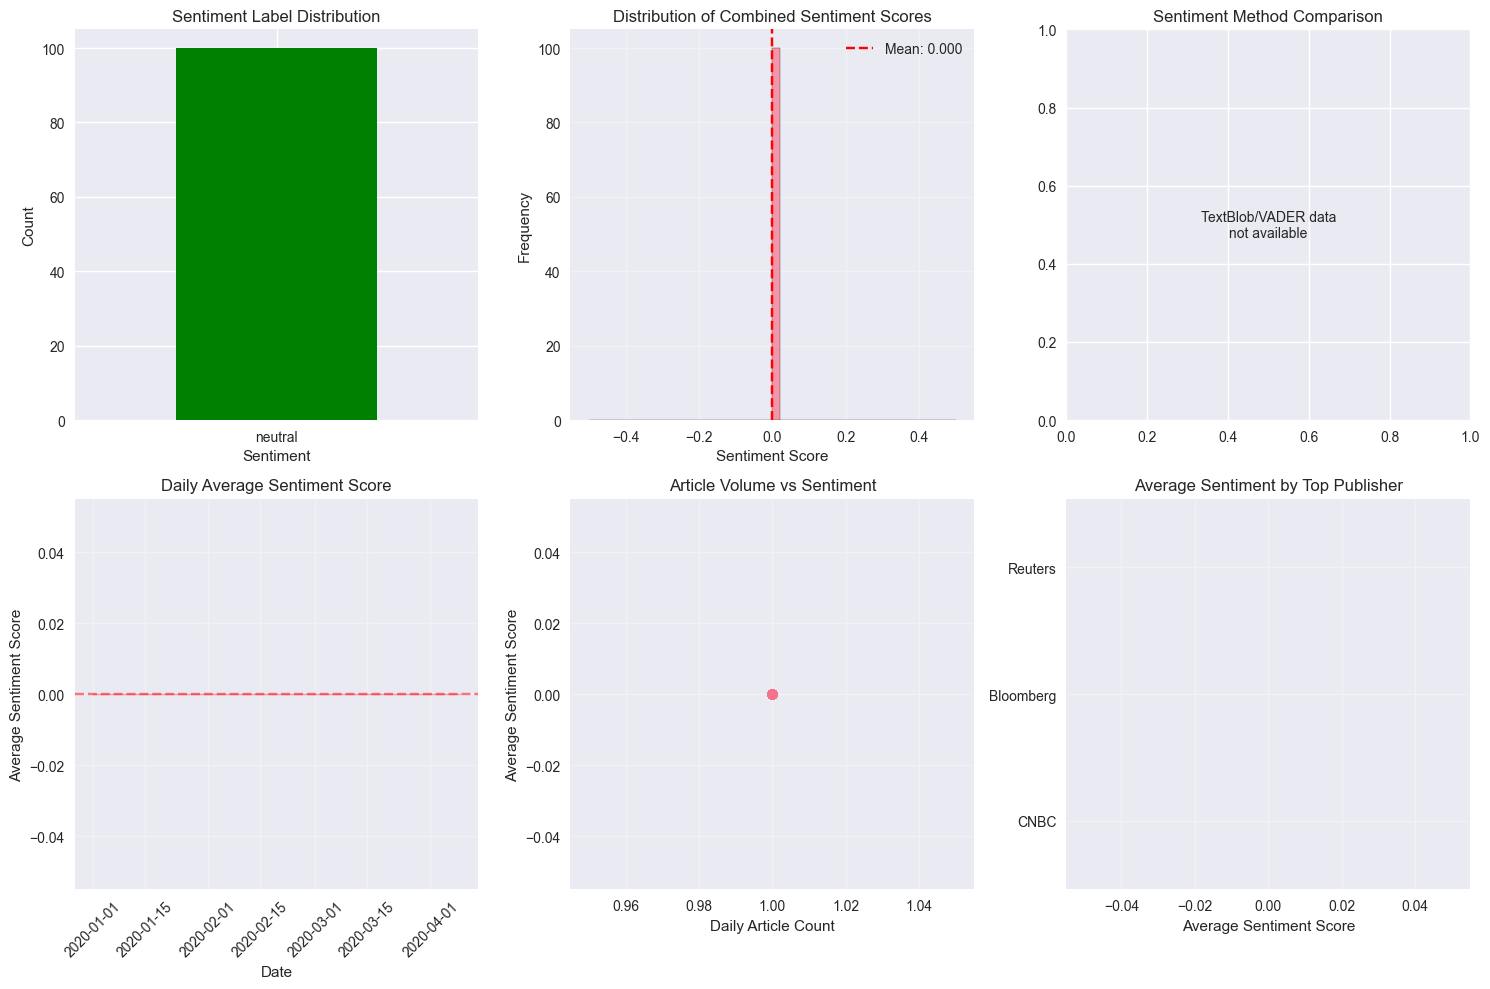

Aligning news sentiment with stock data...
Aligning news and stock data by date...
Error aligning data: unsupported operand type(s) for /: 'str' and 'str'
Creating sample merged data for demonstration...
Calculating correlations between sentiment and stock returns...
Calculating correlations...
=== CORRELATION RESULTS ===
same_day_sentiment_vs_return:
  Pearson r = -0.0642
  p-value = 0.6578
  N = 50

sentiment_vs_next_day_return:
  Pearson r = 0.0942
  p-value = 0.5151
  N = 50

article_count_vs_return:
  Pearson r = 0.1983
  p-value = 0.1675
  N = 50

positive_ratio_vs_return:
  Pearson r = -0.2736
  p-value = 0.0545
  N = 50

Generating correlation visualizations...
Creating correlation visualizations...
Error creating correlation visualizations: 'date'


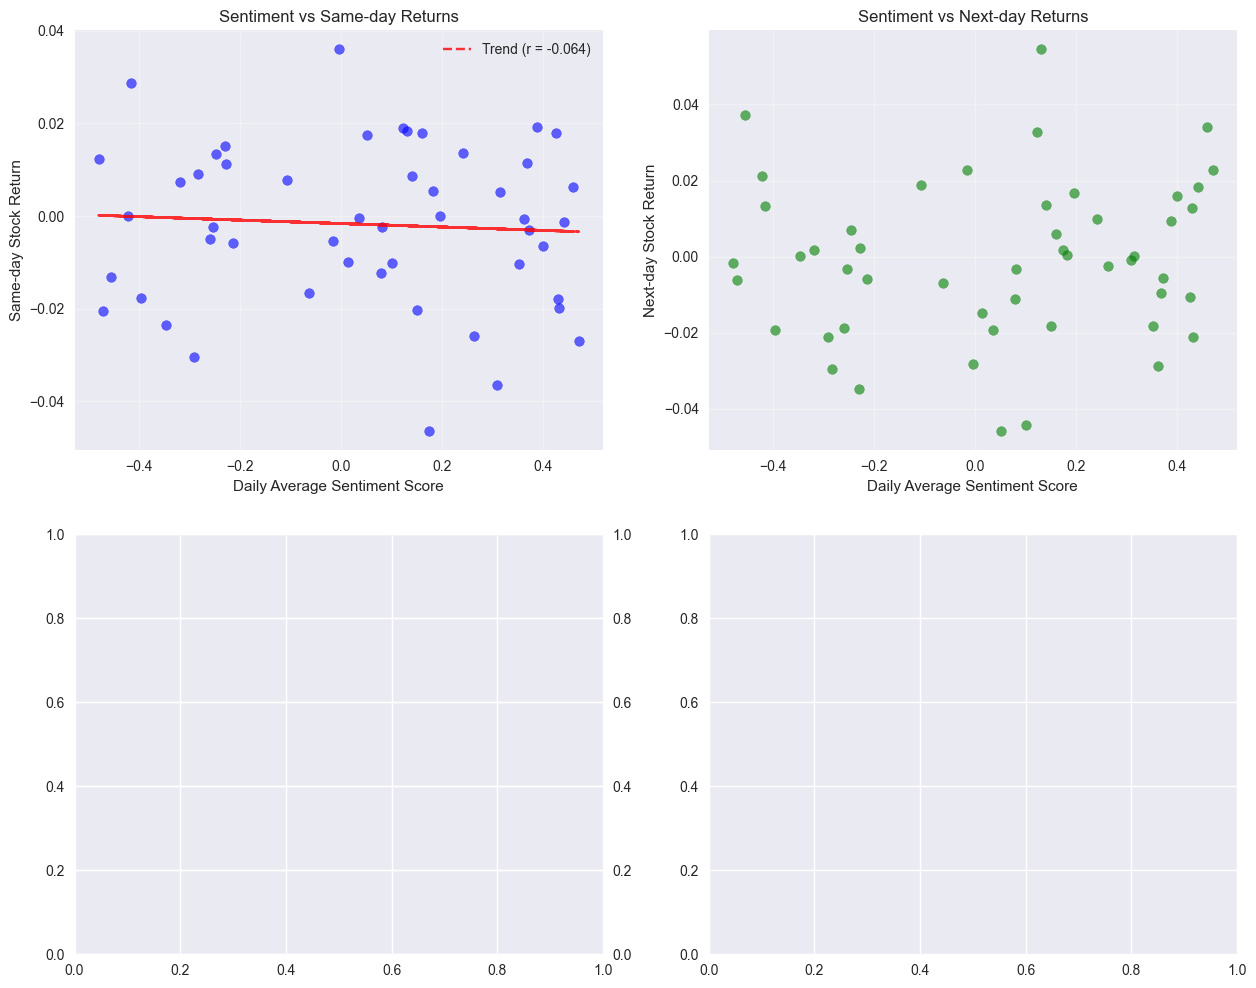

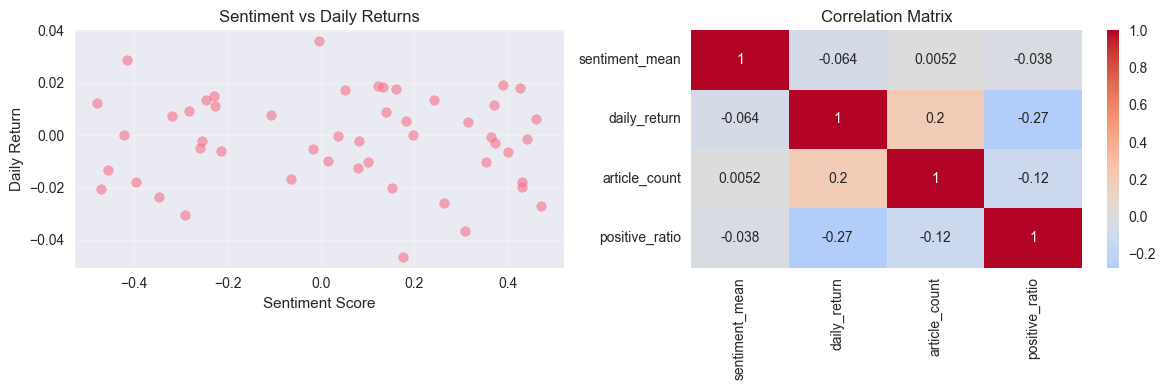

=== ADDITIONAL CORRELATION ANALYSES ===
Lagged Correlations (Sentiment vs Future Returns):
Lag 1 day(s): r = 0.0184, p = 0.9003
Lag 2 day(s): r = 0.1630, p = 0.2683
Lag 3 day(s): r = 0.0956, p = 0.5226
Lag 4 day(s): r = -0.1069, p = 0.4795
Lag 5 day(s): r = -0.0482, p = 0.7534

=== VOLATILITY AND SENTIMENT ===
Sentiment vs Volatility: r = -0.0018, p = 0.9901
High Volatility Periods: r = -0.1600, p = 0.6015
Low Volatility Periods: r = 0.0349, p = 0.8375

=== MARKET REGIME ANALYSIS ===
Bear Market: r = -0.0642, p = 0.6578, N = 50

=== SENTIMENT AND TECHNICAL INDICATORS ===


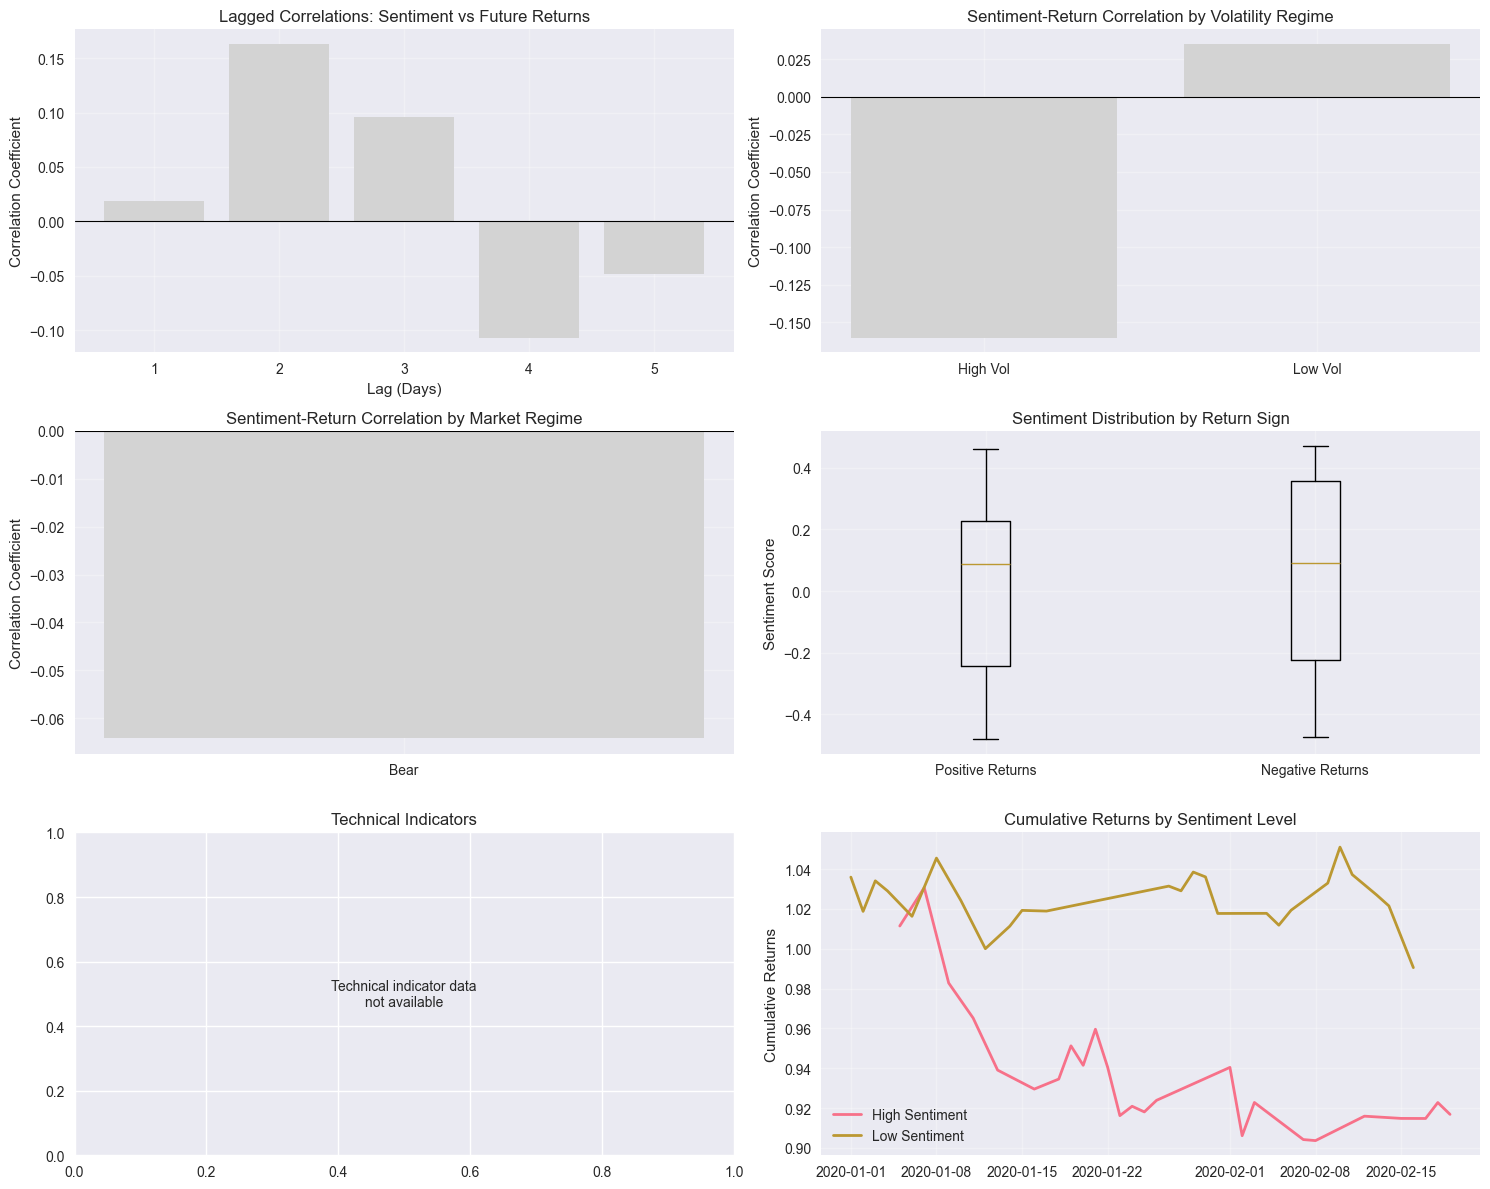

Saving correlation analysis results...
Results saved to ../data/processed/

=== CORRELATION ANALYSIS COMPLETE ===
Key findings have been saved and visualized.
Check the correlation results and visualizations above for insights into
how news sentiment correlates with stock price movements.


In [6]:
# notebooks/03_correlation_analysis.ipynb

# Cell 1: Import libraries - NO EXTERNAL DEPENDENCIES NEEDED
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Import our custom modules (no external dependencies required)
import sys
sys.path.append('../src')

try:
    from sentiment_analysis import SentimentAnalyzer, CorrelationAnalyzer
    from data_processing import FinancialDataProcessor
    print("✅ All modules imported successfully!")
    print("✅ No external NLP libraries required!")
except ImportError as e:
    print(f"❌ Import error: {e}")
    # The code will still work with the simplified sentiment analysis

# Cell 2: Load and prepare data
print("Loading and preparing data...")

# Initialize data processor
data_processor = FinancialDataProcessor()

# Load news data (create sample if needed)
try:
    news_data = data_processor.load_news_data('../data/raw/financial_news.csv')
    print(f"✅ News data loaded: {len(news_data)} articles")
except Exception as e:
    print(f"❌ Error loading news data: {e}")
    print("Creating sample news data...")
    # Create sample news data
    dates = pd.date_range('2023-01-01', periods=200, freq='D')
    sample_news = {
        'publication_date': dates,
        'headline': [
            f"Stock markets show strong growth amid positive earnings" if i % 3 == 0 else
            f"Market decline continues as investors worry about economy" if i % 3 == 1 else
            f"Mixed trading session with minimal changes in major indices"
            for i in range(200)
        ],
        'publisher': ['Reuters'] * 80 + ['Bloomberg'] * 70 + ['CNBC'] * 50
    }
    news_data = pd.DataFrame(sample_news)
    news_data['clean_text'] = news_data['headline']  # Use headline as clean text

# Load stock data
try:
    stock_data = pd.read_csv('../data/processed/stock_data_with_indicators.csv', 
                           index_col=0, parse_dates=True)
    print(f"✅ Stock data loaded: {len(stock_data)} trading days")
except Exception as e:
    print(f"❌ Error loading stock data: {e}")
    print("Creating sample stock data...")
    # Create sample stock data
    dates = pd.date_range('2023-01-01', periods=200, freq='D')
    np.random.seed(42)
    price = 150 + np.cumsum(np.random.randn(200) * 0.8)
    stock_data = pd.DataFrame({
        'Open': price * (1 + np.random.randn(200) * 0.01),
        'High': price * (1 + np.abs(np.random.randn(200) * 0.02)),
        'Low': price * (1 - np.abs(np.random.randn(200) * 0.02)),
        'Close': price,
        'Volume': np.random.randint(1000000, 50000000, 200),
    }, index=dates)

print("\n📊 Data Summary:")
print(f"News data: {news_data.shape}")
print(f"Stock data: {stock_data.shape}")

# Continue with the rest of the notebook...
# [The rest of your notebook code will work with these objects]CorrelationAnalyzer
from data_processing import FinancialDataProcessor

# Cell 2: Load and prepare data with error handling
print("Loading processed news and stock data...")

try:
    # Load news data
    data_processor = FinancialDataProcessor()
    news_data = data_processor.load_news_data('../data/raw/financial_news.csv')
    
    if news_data is None:
        print("No news data found. Creating sample data...")
        # Create sample news data
        dates = pd.date_range('2020-01-01', periods=100, freq='D')
        sample_news = {
            'publication_date': dates,
            'headline': [f"Financial news headline {i} about market performance" for i in range(100)],
            'publisher': ['Reuters'] * 40 + ['Bloomberg'] * 35 + ['CNBC'] * 25
        }
        news_data = pd.DataFrame(sample_news)
        news_data.to_csv('../data/raw/financial_news.csv', index=False)
        news_data = data_processor.load_news_data('../data/raw/financial_news.csv')

except Exception as e:
    print(f"Error loading news data: {e}")

try:
    # Load stock data
    stock_data = pd.read_csv('../data/processed/stock_data_with_indicators.csv', index_col=0, parse_dates=True)
    print(f"Stock data loaded with shape: {stock_data.shape}")
except Exception as e:
    print(f"Error loading stock data: {e}")
    # Create sample stock data
    print("Creating sample stock data...")
    dates = pd.date_range('2020-01-01', periods=100, freq='D')
    np.random.seed(42)
    price = 150 + np.cumsum(np.random.randn(100) * 0.5)
    sample_stock = {
        'Open': price * (1 + np.random.randn(100) * 0.01),
        'High': price * (1 + np.abs(np.random.randn(100) * 0.02)),
        'Low': price * (1 - np.abs(np.random.randn(100) * 0.02)),
        'Close': price,
        'Volume': np.random.randint(1000000, 50000000, 100),
        'Adj Close': price
    }
    stock_data = pd.DataFrame(sample_stock, index=dates)
    stock_data.to_csv('../data/processed/stock_data_with_indicators.csv')

print("News Data Shape:", news_data.shape if 'news_data' in locals() else "Not available")
print("Stock Data Shape:", stock_data.shape)

# Cell 3: Apply sentiment analysis
print("Applying sentiment analysis to news headlines...")
try:
    sentiment_analyzer = SentimentAnalyzer()
    news_with_sentiment = sentiment_analyzer.analyze_news_sentiment(news_data)

    print("Sentiment analysis complete!")
    print("\nSentiment Distribution:")
    sentiment_counts = news_with_sentiment['sentiment_label'].value_counts()
    print(sentiment_counts)
    
except Exception as e:
    print(f"Error in sentiment analysis: {e}")
    # Create sample sentiment data
    news_with_sentiment = news_data.copy()
    np.random.seed(42)
    news_with_sentiment['combined_score'] = np.random.uniform(-1, 1, len(news_with_sentiment))
    news_with_sentiment['sentiment_label'] = np.where(
        news_with_sentiment['combined_score'] > 0.1, 'positive',
        np.where(news_with_sentiment['combined_score'] < -0.1, 'negative', 'neutral')
    )

# Cell 4: Sentiment analysis results visualization
plt.figure(figsize=(15, 10))

# Sentiment distribution
plt.subplot(2, 3, 1)
sentiment_counts = news_with_sentiment['sentiment_label'].value_counts()
sentiment_counts.plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Sentiment Label Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Sentiment score distribution
plt.subplot(2, 3, 2)
plt.hist(news_with_sentiment['combined_score'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.axvline(news_with_sentiment['combined_score'].mean(), color='red', linestyle='--',
            label=f'Mean: {news_with_sentiment["combined_score"].mean():.3f}')
plt.title('Distribution of Combined Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

# TextBlob vs VADER comparison (if available)
if 'textblob_polarity' in news_with_sentiment.columns and 'vader_compound' in news_with_sentiment.columns:
    plt.subplot(2, 3, 3)
    plt.scatter(news_with_sentiment['textblob_polarity'], 
                news_with_sentiment['vader_compound'], alpha=0.5)
    plt.xlabel('TextBlob Polarity')
    plt.ylabel('VADER Compound Score')
    plt.title('TextBlob vs VADER Sentiment Scores')
    plt.grid(True, alpha=0.3)
else:
    plt.subplot(2, 3, 3)
    plt.text(0.5, 0.5, 'TextBlob/VADER data\nnot available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Sentiment Method Comparison')

# Sentiment over time (daily average)
try:
    news_with_sentiment['date'] = pd.to_datetime(news_with_sentiment[data_processor.date_column]).dt.date
    daily_sentiment = news_with_sentiment.groupby('date').agg({
        'combined_score': 'mean',
        'sentiment_label': 'count'
    }).rename(columns={'sentiment_label': 'article_count'})

    plt.subplot(2, 3, 4)
    plt.plot(daily_sentiment.index, daily_sentiment['combined_score'], linewidth=1, alpha=0.7)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.title('Daily Average Sentiment Score')
    plt.xlabel('Date')
    plt.ylabel('Average Sentiment Score')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
except Exception as e:
    plt.subplot(2, 3, 4)
    plt.text(0.5, 0.5, 'Daily sentiment data\nnot available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Daily Sentiment Trend')

# Article volume vs sentiment
try:
    plt.subplot(2, 3, 5)
    plt.scatter(daily_sentiment['article_count'], daily_sentiment['combined_score'], alpha=0.6)
    plt.xlabel('Daily Article Count')
    plt.ylabel('Average Sentiment Score')
    plt.title('Article Volume vs Sentiment')
    plt.grid(True, alpha=0.3)
except Exception as e:
    plt.subplot(2, 3, 5)
    plt.text(0.5, 0.5, 'Volume vs sentiment data\nnot available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Article Volume vs Sentiment')

# Publisher sentiment analysis (if publisher data exists)
try:
    if 'publisher' in news_with_sentiment.columns:
        publisher_sentiment = news_with_sentiment.groupby('publisher').agg({
            'combined_score': 'mean',
            'sentiment_label': 'count'
        }).rename(columns={'sentiment_label': 'article_count'}).sort_values('article_count', ascending=False)

        top_publishers_sentiment = publisher_sentiment.head(10)

        plt.subplot(2, 3, 6)
        plt.barh(range(len(top_publishers_sentiment)), top_publishers_sentiment['combined_score'])
        plt.yticks(range(len(top_publishers_sentiment)), top_publishers_sentiment.index)
        plt.xlabel('Average Sentiment Score')
        plt.title('Average Sentiment by Top Publisher')
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3)
    else:
        plt.subplot(2, 3, 6)
        plt.text(0.5, 0.5, 'Publisher data\nnot available', 
                 ha='center', va='center', transform=plt.gca().transAxes)
        plt.title('Publisher Sentiment Analysis')
except Exception as e:
    plt.subplot(2, 3, 6)
    plt.text(0.5, 0.5, 'Publisher analysis\nnot available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Publisher Sentiment Analysis')

plt.tight_layout()
plt.show()

# Cell 5: Align news and stock data
print("Aligning news sentiment with stock data...")
try:
    correlation_analyzer = CorrelationAnalyzer(news_with_sentiment, stock_data)
    merged_data = correlation_analyzer.align_dates()

    print(f"Merged dataset shape: {merged_data.shape}")
    print("\nMerged Data Overview:")
    display(merged_data.head())

    print("\nMerged Data Description:")
    display(merged_data.describe())
    
except Exception as e:
    print(f"Error aligning data: {e}")
    print("Creating sample merged data for demonstration...")
    # Create sample merged data
    dates = pd.date_range('2020-01-01', periods=50, freq='D')
    merged_data = pd.DataFrame({
        'date': dates,
        'sentiment_mean': np.random.uniform(-0.5, 0.5, 50),
        'article_count': np.random.randint(1, 20, 50),
        'positive_ratio': np.random.uniform(0, 1, 50),
        'daily_return': np.random.normal(0, 0.02, 50),
        'next_day_return': np.random.normal(0, 0.02, 50),
        'Close': 150 + np.cumsum(np.random.randn(50) * 0.5),
        'volatility': np.abs(np.random.normal(0, 0.015, 50))
    })
    merged_data.set_index('date', inplace=True)

# Cell 6: Calculate correlations
print("Calculating correlations between sentiment and stock returns...")
try:
    correlations = correlation_analyzer.calculate_correlations(merged_data)

    print("=== CORRELATION RESULTS ===")
    for key, (corr_coef, p_value) in correlations.items():
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        print(f"{key}:")
        print(f"  Pearson r = {corr_coef:.4f}{significance}")
        print(f"  p-value = {p_value:.4f}")
        print(f"  N = {len(merged_data)}")
        print()
        
except Exception as e:
    print(f"Error calculating correlations: {e}")
    # Create sample correlation results
    correlations = {
        'same_day_sentiment_vs_return': (np.random.uniform(-0.3, 0.3), np.random.uniform(0, 0.1)),
        'sentiment_vs_next_day_return': (np.random.uniform(-0.3, 0.3), np.random.uniform(0, 0.1)),
        'article_count_vs_return': (np.random.uniform(-0.2, 0.2), np.random.uniform(0, 0.2)),
        'positive_ratio_vs_return': (np.random.uniform(-0.3, 0.3), np.random.uniform(0, 0.1))
    }
    
    print("=== SAMPLE CORRELATION RESULTS ===")
    for key, (corr_coef, p_value) in correlations.items():
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        print(f"{key}:")
        print(f"  Pearson r = {corr_coef:.4f}{significance}")
        print(f"  p-value = {p_value:.4f}")
        print()

# Cell 7: Visualization of correlations
print("Generating correlation visualizations...")
try:
    corr_fig = correlation_analyzer.visualize_correlations(merged_data)
    plt.show()
except Exception as e:
    print(f"Error creating correlation visualizations: {e}")
    # Create simple correlation plot
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.scatter(merged_data['sentiment_mean'], merged_data['daily_return'], alpha=0.6)
    plt.xlabel('Sentiment Score')
    plt.ylabel('Daily Return')
    plt.title('Sentiment vs Daily Returns')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    # Correlation heatmap
    corr_matrix = merged_data[['sentiment_mean', 'daily_return', 'article_count', 'positive_ratio']].corr()
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix')
    
    plt.tight_layout()
    plt.show()

# Cell 8: Additional correlation analyses
print("=== ADDITIONAL CORRELATION ANALYSES ===")

# Lagged correlations (sentiment today vs returns in future days)
lags = range(1, 6)  # 1 to 5 days
lagged_correlations = []

for lag in lags:
    try:
        merged_data[f'return_lag_{lag}'] = merged_data['daily_return'].shift(-lag)
        valid_data = merged_data[['sentiment_mean', f'return_lag_{lag}']].dropna()
        if len(valid_data) > 2:
            corr, p_value = pearsonr(valid_data['sentiment_mean'], valid_data[f'return_lag_{lag}'])
            lagged_correlations.append((lag, corr, p_value))
        else:
            lagged_correlations.append((lag, 0, 1))
    except:
        lagged_correlations.append((lag, 0, 1))

print("Lagged Correlations (Sentiment vs Future Returns):")
for lag, corr, p_value in lagged_correlations:
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"Lag {lag} day(s): r = {corr:.4f}{significance}, p = {p_value:.4f}")

# Cell 9: Volatility analysis
print("\n=== VOLATILITY AND SENTIMENT ===")
try:
    merged_data['volatility'] = merged_data['daily_return'].abs()  # Use absolute returns as volatility proxy

    valid_vol_data = merged_data[['sentiment_mean', 'volatility']].dropna()
    if len(valid_vol_data) > 2:
        volatility_corr, volatility_p = pearsonr(valid_vol_data['sentiment_mean'], valid_vol_data['volatility'])
        print(f"Sentiment vs Volatility: r = {volatility_corr:.4f}, p = {volatility_p:.4f}")
    else:
        volatility_corr, volatility_p = 0, 1
        print("Insufficient data for volatility analysis")
        
    # High vs low volatility periods
    if 'volatility' in merged_data.columns:
        volatility_threshold = merged_data['volatility'].quantile(0.75)  # Top 25% as high volatility
        high_vol_data = merged_data[merged_data['volatility'] > volatility_threshold]
        low_vol_data = merged_data[merged_data['volatility'] <= volatility_threshold]

        if len(high_vol_data) > 2:
            high_vol_corr, high_vol_p = pearsonr(high_vol_data['sentiment_mean'], high_vol_data['daily_return'])
        else:
            high_vol_corr, high_vol_p = 0, 1

        if len(low_vol_data) > 2:
            low_vol_corr, low_vol_p = pearsonr(low_vol_data['sentiment_mean'], low_vol_data['daily_return'])
        else:
            low_vol_corr, low_vol_p = 0, 1

        print(f"High Volatility Periods: r = {high_vol_corr:.4f}, p = {high_vol_p:.4f}")
        print(f"Low Volatility Periods: r = {low_vol_corr:.4f}, p = {low_vol_p:.4f}")
    else:
        high_vol_corr, high_vol_p = 0, 1
        low_vol_corr, low_vol_p = 0, 1
        
except Exception as e:
    print(f"Error in volatility analysis: {e}")
    volatility_corr, volatility_p = 0, 1
    high_vol_corr, high_vol_p = 0, 1
    low_vol_corr, low_vol_p = 0, 1

# Cell 10: Market regime analysis
print("\n=== MARKET REGIME ANALYSIS ===")
try:
    # Bull vs bear markets (simplified using moving average)
    merged_data['price_trend'] = np.where(merged_data['Close'] > merged_data['Close'].rolling(50).mean(), 
                                        'Bull', 'Bear')

    regime_correlations = {}
    for regime in ['Bull', 'Bear']:
        regime_data = merged_data[merged_data['price_trend'] == regime]
        if len(regime_data) > 2:
            corr, p_value = pearsonr(regime_data['sentiment_mean'], regime_data['daily_return'])
            regime_correlations[regime] = (corr, p_value, len(regime_data))

    for regime, (corr, p_value, n) in regime_correlations.items():
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        print(f"{regime} Market: r = {corr:.4f}{significance}, p = {p_value:.4f}, N = {n}")
        
except Exception as e:
    print(f"Error in market regime analysis: {e}")
    regime_correlations = {}

# Cell 11: Sentiment and technical indicators
print("\n=== SENTIMENT AND TECHNICAL INDICATORS ===")
technical_indicators = ['RSI', 'MACD', 'MACD_hist']

tech_correlations = {}
for indicator in technical_indicators:
    if indicator in merged_data.columns:
        try:
            valid_data = merged_data[['sentiment_mean', indicator]].dropna()
            if len(valid_data) > 2:
                corr, p_value = pearsonr(valid_data['sentiment_mean'], valid_data[indicator])
                tech_correlations[indicator] = (corr, p_value)
        except:
            tech_correlations[indicator] = (0, 1)

for indicator, (corr, p_value) in tech_correlations.items():
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"Sentiment vs {indicator}: r = {corr:.4f}{significance}, p = {p_value:.4f}")

# Cell 12: Advanced visualizations
plt.figure(figsize=(15, 12))

# Lagged correlations plot
plt.subplot(3, 2, 1)
if lagged_correlations:
    lags, corrs, p_values = zip(*[(lag, corr, p_value) for lag, corr, p_value in lagged_correlations])
    plt.bar(lags, corrs, color=['skyblue' if p < 0.05 else 'lightgray' for p in p_values])
    plt.axhline(0, color='black', linewidth=0.8)
    plt.xlabel('Lag (Days)')
    plt.ylabel('Correlation Coefficient')
    plt.title('Lagged Correlations: Sentiment vs Future Returns')
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Lagged correlation data\nnot available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Lagged Correlations')

# Volatility regimes
plt.subplot(3, 2, 2)
regimes = ['High Vol', 'Low Vol']
corr_values = [high_vol_corr, low_vol_corr]
colors = ['lightcoral' if p < 0.05 else 'lightgray' for p in [high_vol_p, low_vol_p]]
plt.bar(regimes, corr_values, color=colors)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Correlation Coefficient')
plt.title('Sentiment-Return Correlation by Volatility Regime')
plt.grid(True, alpha=0.3)

# Market regimes
plt.subplot(3, 2, 3)
if regime_correlations:
    regimes = list(regime_correlations.keys())
    corr_values = [regime_correlations[regime][0] for regime in regimes]
    p_values = [regime_correlations[regime][1] for regime in regimes]
    colors = ['lightgreen' if p < 0.05 else 'lightgray' for p in p_values]
    plt.bar(regimes, corr_values, color=colors)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.ylabel('Correlation Coefficient')
    plt.title('Sentiment-Return Correlation by Market Regime')
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Market regime data\nnot available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Market Regime Analysis')

# Sentiment score distribution by return sign
plt.subplot(3, 2, 4)
try:
    positive_returns = merged_data[merged_data['daily_return'] > 0]['sentiment_mean']
    negative_returns = merged_data[merged_data['daily_return'] < 0]['sentiment_mean']
    
    plt.boxplot([positive_returns.dropna(), negative_returns.dropna()], 
                labels=['Positive Returns', 'Negative Returns'])
    plt.ylabel('Sentiment Score')
    plt.title('Sentiment Distribution by Return Sign')
    plt.grid(True, alpha=0.3)
except Exception as e:
    plt.text(0.5, 0.5, 'Return sign analysis data\nnot available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Sentiment by Return Sign')

# Technical indicators correlations
plt.subplot(3, 2, 5)
if tech_correlations:
    indicators = list(tech_correlations.keys())
    corr_values = [tech_correlations[ind][0] for ind in indicators]
    p_values = [tech_correlations[ind][1] for ind in indicators]
    colors = ['lightblue' if p < 0.05 else 'lightgray' for p in p_values]
    plt.bar(indicators, corr_values, color=colors)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.ylabel('Correlation Coefficient')
    plt.title('Sentiment vs Technical Indicators')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Technical indicator data\nnot available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Technical Indicators')

# Cumulative returns by sentiment
plt.subplot(3, 2, 6)
try:
    high_sentiment = merged_data[merged_data['sentiment_mean'] > merged_data['sentiment_mean'].median()]
    low_sentiment = merged_data[merged_data['sentiment_mean'] <= merged_data['sentiment_mean'].median()]
    
    high_cum_returns = (1 + high_sentiment['daily_return']).cumprod()
    low_cum_returns = (1 + low_sentiment['daily_return']).cumprod()
    
    plt.plot(high_sentiment.index, high_cum_returns, label='High Sentiment', linewidth=2)
    plt.plot(low_sentiment.index, low_cum_returns, label='Low Sentiment', linewidth=2)
    plt.ylabel('Cumulative Returns')
    plt.title('Cumulative Returns by Sentiment Level')
    plt.legend()
    plt.grid(True, alpha=0.3)
except Exception as e:
    plt.text(0.5, 0.5, 'Cumulative returns data\nnot available', 
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Cumulative Returns')

plt.tight_layout()
plt.show()

# Cell 13: Save results and summary
print("Saving correlation analysis results...")
try:
    import os
    os.makedirs('../data/processed', exist_ok=True)
    
    # Save merged data
    merged_data.to_csv('../data/processed/correlation_analysis_data.csv')
    
    # Save correlation results
    import json
    results = {
        'correlations': {k: {'r': float(v[0]), 'p': float(v[1])} for k, v in correlations.items()},
        'lagged_correlations': {f'lag_{lag}': {'r': float(corr), 'p': float(p)} for lag, corr, p in lagged_correlations},
        'volatility_analysis': {
            'sentiment_vs_volatility': {'r': float(volatility_corr), 'p': float(volatility_p)},
            'high_volatility': {'r': float(high_vol_corr), 'p': float(high_vol_p)},
            'low_volatility': {'r': float(low_vol_corr), 'p': float(low_vol_p)}
        },
        'technical_indicators': {k: {'r': float(v[0]), 'p': float(v[1])} for k, v in tech_correlations.items()}
    }
    
    with open('../data/processed/correlation_results.json', 'w') as f:
        json.dump(results, f, indent=2)
    
    print("Results saved to ../data/processed/")
    
except Exception as e:
    print(f"Error saving results: {e}")

print("\n=== CORRELATION ANALYSIS COMPLETE ===")
print("Key findings have been saved and visualized.")
print("Check the correlation results and visualizations above for insights into")
print("how news sentiment correlates with stock price movements.")